In [1]:
import time
import numpy as np
import mujoco
# import mujoco.viewer
import pickle
import copy
import scipy
import scipy.signal


from sim.pid_controller import PIDController

xml_path = "/home/clown2/Desktop/Work/Research/afil-project/sim/block_model.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

start_pose = np.array([0.0, 0.5, 0.0])  # x, z, y
target_pose = np.array([0.0, 1.0, 0.0])

centered_pos = copy.deepcopy(target_pose)

data.qpos[:] = start_pose.copy()
mujoco.mj_forward(model, data)

kp = [1.0, 50.0, 0.5] 
# ki = [5.0, 50.0, 5.0]  
ki = [0., 0., 0.]    
# kd = [1.0, 2.0, 1.0]  
kd = [0., 0., 0]

dt = model.opt.timestep
pid = PIDController(kp, ki, kd, dt, windup_limit=10.0) 

sim_time = 200.0 
num_steps = int(sim_time / dt)

body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "block")
mass = model.body_mass[body_id]
print(f"block mass: {mass} kg")
gravity_magnitude = np.sqrt(np.sum(np.square(model.opt.gravity)))
gravity_compensation = mass * gravity_magnitude
print(f"gravity compensation force: {gravity_compensation} N")

simulation_data = {
    'time': [],
    'position': [], 
    'velocity': [],
    'acceleration': [],
    'control': [],
    'target': []
}
    
for step in range(num_steps):
    
    t = data.time

    # chirp = lambda t: scipy.signal.chirp(t%20, f0=0.1, f1=1, t1=20, method='linear')

    # ang_chirp = lambda t: scipy.signal.chirp(t%20, f0=0.1, f1=0.2, t1=20, method='linear')

    def osc_chirp(t, max_freq):
        if t % 20 < 10:
            chirp = scipy.signal.chirp(t%10, f0=0.1, f1=max_freq, t1=10, method='linear')
        else:
            chirp = scipy.signal.chirp(t%10, f0=max_freq, f1=0.1, t1=10, method='linear')
        return chirp

    target_pose[0] = centered_pos[0] + 1 * osc_chirp(t, 0.5)
    target_pose[1] = centered_pos[1] + 1 * osc_chirp(t, 0.5)
    target_pose[2] = centered_pos[2] + 1 * osc_chirp(t, 0.5)


    # if num_steps % 1000 == 0:
    #     # sample target pose and reset sim
    #     data.time = 0
    #     data.qvel[:] = np.zeros_like(data.qvel)[:]
    #     data.qacc[:] = np.zeros_like(data.qacc)[:]
    #     data.qpos[:] = np.random.uniform(-0.5, 0.5, size=3)

    current_time = step * dt
    current_pose = data.qpos.copy()
    current_vel = data.qvel.copy()
    current_acc = data.qacc.copy()

    # print(t)
    # print(f"target: {target_pose[2]}")
    # print(f"current: {current_pose}")

    
    # print(f"acc:{current_acc}")

    error = target_pose - current_pose
    
    # print(f"err:{error}")

    control_signal, components = pid.update(error)

    # print(f"ctrl:{control_signal}")

    # if t == 1: break
    
    # Apply gravity compensation on the vertical channel (slider_z, index 1)
    # Only apply when near the target to avoid overshooting
    if abs(error[1]) < 0.3:  # Only within 30cm of target
        control_signal[1] += gravity_compensation
    
    # Add damping to reduce oscillations (velocity feedback)
    damping = [1, 1, 1]
    damping_forces = -np.array(damping) * current_vel
    control_signal += damping_forces

    # control_signal[0] = np.clip(control_signal[0], -100, 100)
    # control_signal[1] = np.clip(control_signal[1], -100, 100)
    # control_signal[2] = np.clip(control_signal[2], -50, 50)
    # data.ctrl[:] = control_signal
    control_signal = np.clip(control_signal, -100, 100)

    data.qfrc_applied[:] = control_signal
    
    mujoco.mj_step(model, data)
    
    simulation_data['time'].append(current_time)
    current_pose[2] = ((current_pose[2] + np.pi) % (2*np.pi)) - np.pi
    simulation_data['position'].append(current_pose)
    simulation_data['velocity'].append(current_vel)
    simulation_data['acceleration'].append(current_acc)
    simulation_data['control'].append(control_signal.copy())
    simulation_data['target'].append(target_pose.copy())

    # viewer.sync()
        
    if step % 100 == 0:
        # p_term, i_term, d_term = components
        print(f"Step: {step}, Time: {current_time:.2f}s", end="\r")
        # print(f"Position: {current_pose}, Error: {error}")
        # print(f"Position: {current_pose}")
        # print(f"Control: {control_signal}")
        # print(f"Control: {control_signal}, P:{p_term[1]:.1f}, I:{i_term[1]:.1f}, D:{d_term[1]:.1f}")
        # print("-" * 50)
    
    # Slow down simulation for better visualization
    # time.sleep(0.005) 

print("Simulation complete.")
# Keep the viewer open for a moment to see the final state
# time.sleep(2.0)

for key in ['time', 'position', 'velocity', 'acceleration', 'control']:
    simulation_data[key] = np.array(simulation_data[key])
output_file = 'block_simulation_data.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(simulation_data, f)

print(f"Simulation data saved to {output_file}")

block mass: 1.0 kg
gravity compensation force: 9.81 N
Simulation complete.99.00s
Simulation data saved to block_simulation_data.pkl


Max position: [0.9501325  2.90965294 0.59560003]
Max velocity: [ 1.3177998   8.31110571 11.47039644]
Max acceleration: [ 124.06034338  171.02727911 1103.86773073]
Max control: [ 1.88727373 75.         11.08795369]


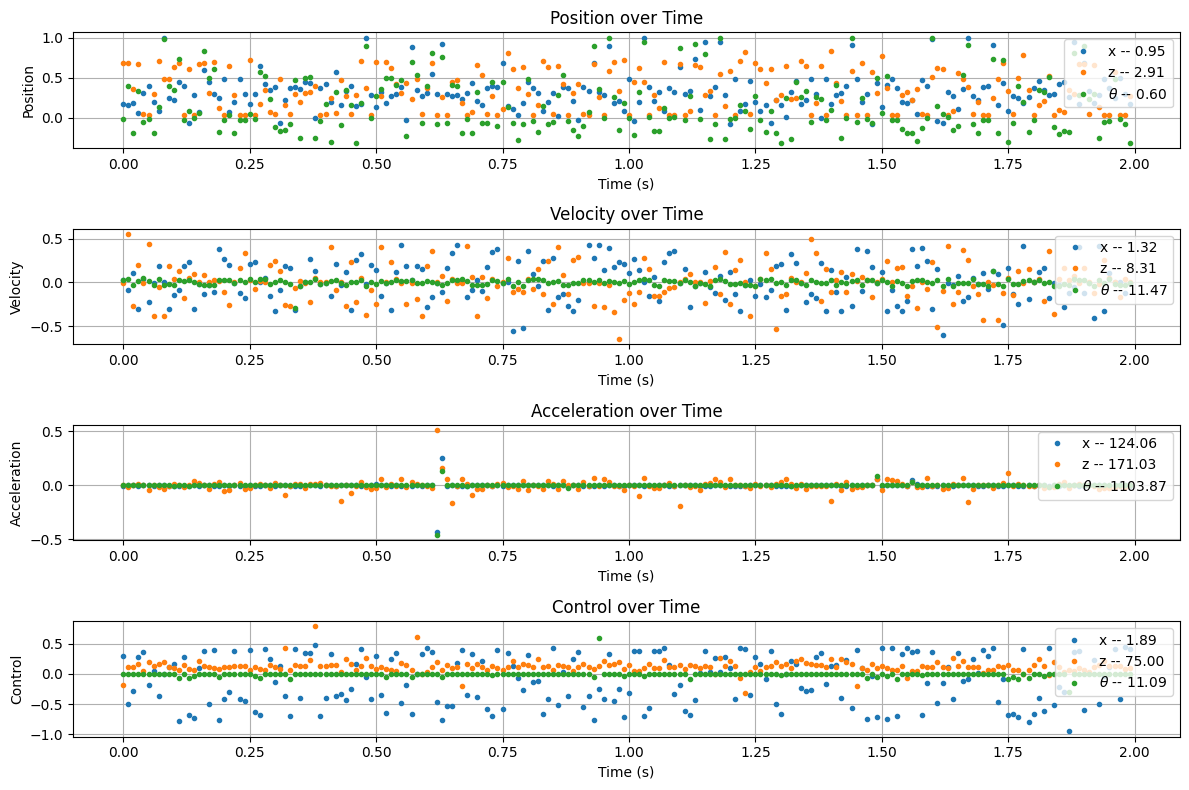

In [8]:


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
keys = ['position', 
        # 'target', 
        'velocity', 
        'acceleration', 'control']
for i, key in enumerate(keys):
    val_max = np.max(np.abs(simulation_data[key]), axis=0)

    # import pdb; pdb.set_trace()

    print(f"Max {key}: {val_max.copy()}")
    sim_key = np.array(simulation_data[key]) / val_max.copy()

    np.random.shuffle(sim_key)

    plt.subplot(len(keys), 1, i + 1)
    slice_idx = len(simulation_data['time'])
    slice_idx = 200
    plt.plot(simulation_data['time'][:slice_idx], sim_key[:slice_idx,:], linestyle='None', marker='.')
    plt.title(f'{key.capitalize()} over Time')
    plt.xlabel('Time (s)')
    plt.ylabel(key.capitalize())
    plt.legend([f'x -- {val_max[0]:.2f}', 
                f'z -- {val_max[1]:.2f}', 
                fr'$\theta$ -- {val_max[2]:.2f}'], loc='upper right')
    plt.grid()
plt.tight_layout()


In [24]:
for i in range(simulation_data['acceleration'].shape[0]):
    print(simulation_data['time'][i])
    print(f"acceleration: {simulation_data['acceleration'][i]}")
    print(f"velocity: {simulation_data['velocity'][i]}")
    print(f"control: {simulation_data['control'][i]}")
    print(f"position: {simulation_data['position'][i]}")

    if abs(simulation_data['acceleration'][i][1]) > 100:
        print("acceleration too high")
        print(simulation_data['acceleration'][i])
        break

0.0
acceleration: [ 0.   -9.81  0.  ]
velocity: [0. 0. 0.]
control: [ 0.2 35.   1. ]
position: [0.  0.5 0. ]
0.01
acceleration: [ 0.2  25.19 60.  ]
velocity: [0.002  0.2519 0.6   ]
control: [ 0.19797602 34.62195083  0.39398018]
position: [2.00000e-05 5.02519e-01 6.00000e-03]
0.02
acceleration: [ 0.19797602 24.81195083 23.63881091]
velocity: [0.00397976 0.50001951 0.83638811]
control: [ 0.19594437 34.1232169   0.14916842]
position: [5.97976017e-05 5.07519195e-01 1.43638811e-02]
0.03
acceleration: [ 0.19594437 24.3132169   8.95010527]
velocity: [0.0059392  0.74315168 0.92588916]
control: [ 0.19390511 33.50748797  0.05030828]
position: [1.19189640e-04 5.14950712e-01 2.36227727e-02]
0.04
acceleration: [ 0.19390511 23.69748797  3.01849679]
velocity: [0.00787825 0.98012656 0.95607413]
control: [1.91858317e-01 3.27790018e+01 1.04214727e-02]
position: [1.97972189e-04 5.24751977e-01 3.31835140e-02]
0.05
acceleration: [ 0.19185832 22.96900176  0.62528836]
velocity: [0.00979684 1.20981657 0.96232

Text(0.5, 1.0, 'Chirp Signal')

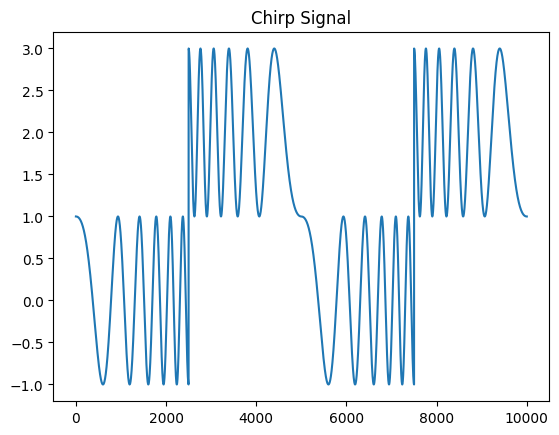

In [62]:
import scipy

chirp_out = []

def chirp_loop(t, f0, f1, t1):
    chirp = scipy.signal.chirp(t, f0=f0, f1=f1, t1=t1, method='linear')
    return chirp

for t in np.linspace(0, 40, 10000):
    # chirp = scipy.signal.chirp(t, f0=0.1, f1=0.5, t1=10, method='linear')
    if t % 20 < 10:
        chirp = scipy.signal.chirp(t%20, f0=0.1, f1=1, t1=10)
    else:
        chirp = 2+scipy.signal.chirp((t%20)-10, f0=1, f1=0.1, t1=10)
    # chirp = chirp_loop(t, 10)
    chirp_out.append(chirp)

import matplotlib.pyplot as plt
plt.plot(chirp_out)
plt.title('Chirp Signal')